In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import joblib

df=pd.read_csv("housee.csv")
df

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1460,5,3,3,2016,Suburb,Average,Yes,1050444
1,4372,5,2,3,2020,Downtown,Poor,Yes,1504239
2,3692,4,2,1,1989,Outskirts,Good,Yes,997830
3,1066,3,1,2,1971,Outskirts,Poor,No,459082
4,4044,3,3,3,2020,Outskirts,Average,Yes,1260317
...,...,...,...,...,...,...,...,...,...
1995,638,1,2,1,2016,Outskirts,Average,No,399134
1996,3144,4,3,3,1999,City Center,Poor,No,1159408
1997,1856,5,1,2,2013,Downtown,Poor,No,1058121
1998,3590,5,2,3,2017,Suburb,Excellent,Yes,1364978


In [5]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1460,5,3,3,2016,Suburb,Average,Yes,1050444
1,4372,5,2,3,2020,Downtown,Poor,Yes,1504239
2,3692,4,2,1,1989,Outskirts,Good,Yes,997830
3,1066,3,1,2,1971,Outskirts,Poor,No,459082
4,4044,3,3,3,2020,Outskirts,Average,Yes,1260317


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Area       2000 non-null   int64 
 1   Bedrooms   2000 non-null   int64 
 2   Bathrooms  2000 non-null   int64 
 3   Floors     2000 non-null   int64 
 4   YearBuilt  2000 non-null   int64 
 5   Location   2000 non-null   object
 6   Condition  2000 non-null   object
 7   Garage     2000 non-null   object
 8   Price      2000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 140.8+ KB


In [7]:
df.describe()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,2825.736500,3.021000,2.547500,1.994000,1996.199500,1.036857e+06
std,1258.916222,1.421115,1.110568,0.810736,15.399067,2.304434e+05
min,601.000000,1.000000,1.000000,1.000000,1970.000000,3.461930e+05
25%,1720.000000,2.000000,2.000000,1.000000,1983.000000,8.854008e+05
50%,2835.500000,3.000000,3.000000,2.000000,1996.000000,1.037607e+06
75%,3902.000000,4.000000,4.000000,3.000000,2009.000000,1.200582e+06
max,4999.000000,5.000000,4.000000,3.000000,2023.000000,1.717223e+06


In [8]:
df.drop(columns =['Floors'],inplace=True)
df

,Area,Bedrooms,Bathrooms,YearBuilt,Location,Condition,Garage,Price
0,1460,5,3,2016,Suburb,Average,Yes,1050444
1,4372,5,2,2020,Downtown,Poor,Yes,1504239
2,3692,4,2,1989,Outskirts,Good,Yes,997830
3,1066,3,1,1971,Outskirts,Poor,No,459082
4,4044,3,3,2020,Outskirts,Average,Yes,1260317
...,...,...,...,...,...,...,...,...
1995,638,1,2,2016,Outskirts,Average,No,399134
1996,3144,4,3,1999,City Center,Poor,No,1159408
1997,1856,5,1,2013,Downtown,Poor,No,1058121
1998,3590,5,2,2017,Suburb,Excellent,Yes,1364978


In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [11]:
num_cols=df.select_dtypes(include='number').columns
df[num_cols]=df[num_cols].fillna(df[num_cols].median())

In [12]:
obj_cols=df.select_dtypes(include='object').columns
df[obj_cols]=df[obj_cols].fillna("None")

In [13]:
df.Location.value_counts()

Location
Downtown       554
Suburb         504
Outskirts      479
City Center    463
Name: count, dtype: int64

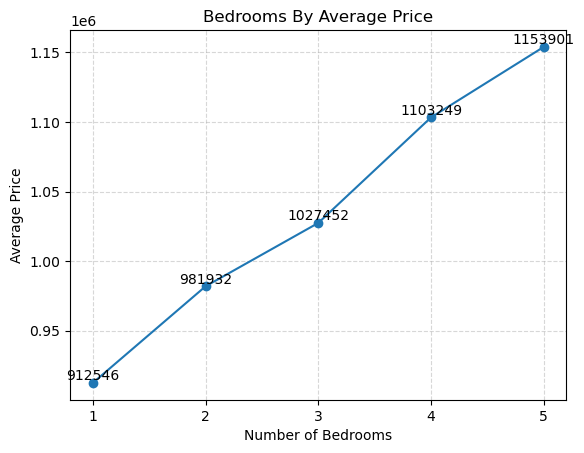

In [15]:
bedroom= df.groupby("Bedrooms")["Price"].mean().astype(int)
plt.plot(bedroom.index, bedroom.values, marker="o")
plt.title("Bedrooms By Average Price")
plt.ylabel("Average Price")
plt.xlabel("Number of Bedrooms")
plt.xticks(bedroom.index.astype(int))
plt.grid(True, linestyle='--', alpha=0.5)
for index, value in zip(bedroom.index, bedroom.values):
    plt.text(index,value,f"{value}",ha='center',va='bottom',fontsize=10)
plt.show()

(array([0, 1, 2, 3]),
 [Text(0, 0, 'City Center'),
  Text(1, 0, 'Downtown'),
  Text(2, 0, 'Outskirts'),
  Text(3, 0, 'Suburb')])

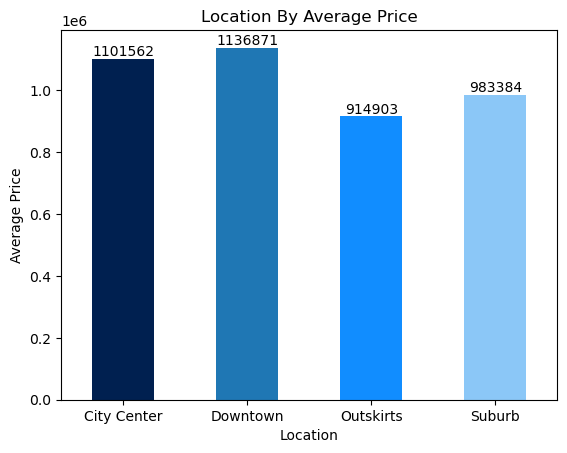

In [16]:
location=df.groupby("Location")["Price"].mean().astype(int)
location.plot(kind="bar", color=["#002050","#1f77b4", "#118DFF", "#8BC7F7"])
plt.title("Location By Average Price")
plt.xlabel("Location")
plt.ylabel("Average Price")
for index, value in enumerate(location.values):
    plt.text(index, value, str(value), ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=360)

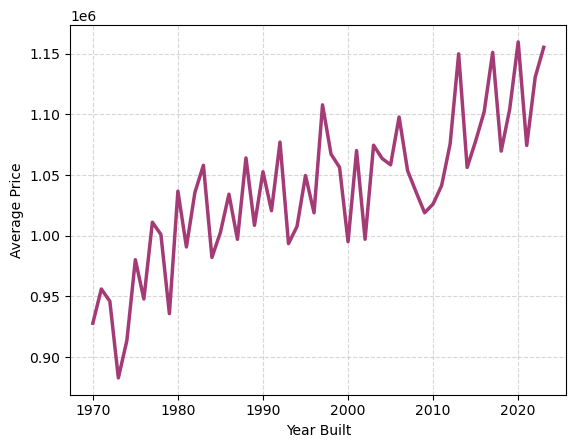

In [17]:
year=df.groupby("YearBuilt")["Price"].mean().astype(int).sort_index()
plt.plot(year.index,year.values,linewidth=2.5,color="#A43B76")
plt.xlabel("Year Built")
plt.ylabel("Average Price")
plt.grid(True,linestyle="--",alpha=0.5)
plt.show()

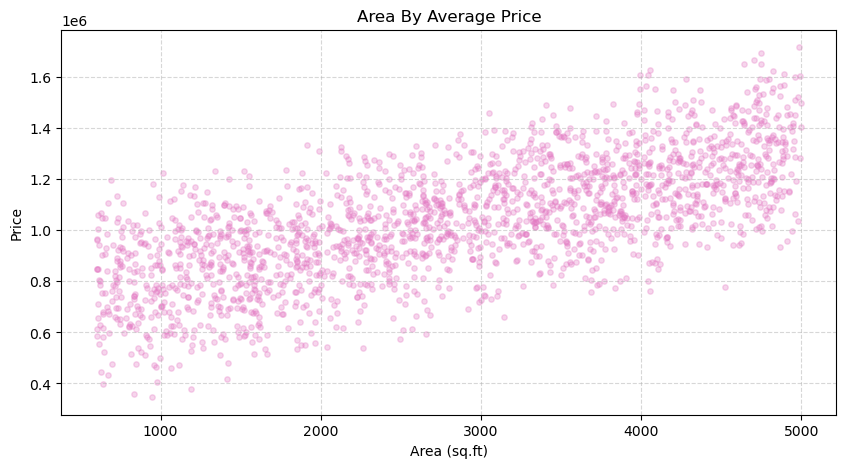

In [18]:
plt.figure(figsize=(10,5))
plt.scatter(df["Area"], df["Price"], color="#e377c2", alpha=0.3, s=15)
plt.title("Area By Average Price")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Price")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

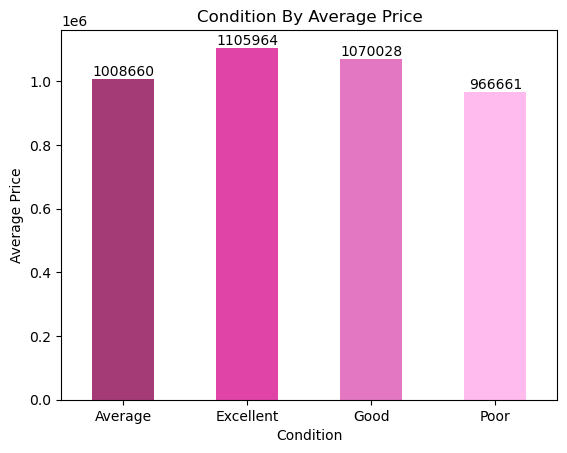

In [19]:
condition=df.groupby("Condition")["Price"].mean().astype(int)
condition.plot(kind="bar", color=["#A43B76","#E044A7", "#e377c2", "#FFBBED"])
plt.title("Condition By Average Price")
plt.xlabel("Condition")
plt.ylabel("Average Price")
plt.xticks(rotation=360)
for index, value in enumerate(condition.values):
    plt.text(index, value, str(value), ha='center', va='bottom', fontsize=10)
plt.show()

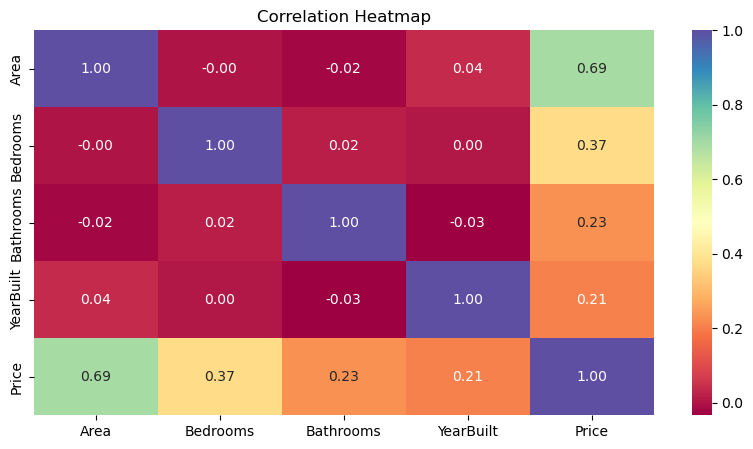

In [20]:
df_num = df.select_dtypes(include=['number'])
corr = df_num.corr()
plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap="Spectral", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
current_year = datetime.datetime.now().year
df['Age'] = current_year - df['YearBuilt']
df = df.drop(columns=['YearBuilt'])
df

,Area,Bedrooms,Bathrooms,Location,Condition,Garage,Price,Age
0,1460,5,3,Suburb,Average,Yes,1050444,10
1,4372,5,2,Downtown,Poor,Yes,1504239,6
2,3692,4,2,Outskirts,Good,Yes,997830,37
3,1066,3,1,Outskirts,Poor,No,459082,55
4,4044,3,3,Outskirts,Average,Yes,1260317,6
...,...,...,...,...,...,...,...,...
1995,638,1,2,Outskirts,Average,No,399134,10
1996,3144,4,3,City Center,Poor,No,1159408,27
1997,1856,5,1,Downtown,Poor,No,1058121,13
1998,3590,5,2,Suburb,Excellent,Yes,1364978,9


In [22]:
X = df.drop('Price', axis=1)   
y = df['Price']

num_features=['Area','Bedrooms','Bathrooms','Age']
cat_features=['Location','Condition','Garage']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
) 

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [24]:
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

print(f'MAE:{mae:.0f},RMSE:{rmse:.0f},R2:{r2:.3f}')

MAE:58575,RMSE:73747,R2:0.901


In [25]:
y_train_pred=pipeline.predict(X_train)
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_pred)
print('Train R2:',train_r2)
print('Test R2:',test_r2)

Train R2: 0.9861492696597113
Test R2: 0.9013858793245313


In [26]:
cv_score=cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='r2'
)
cv_score_rounded = np.round(cv_score, 3)
print("CV R2 Scores:",cv_score_rounded)
print("Average CV R2:",cv_score_rounded.mean())

CV R2 Scores: [0.887 0.897 0.906 0.881 0.919]
Average CV R2: 0.898


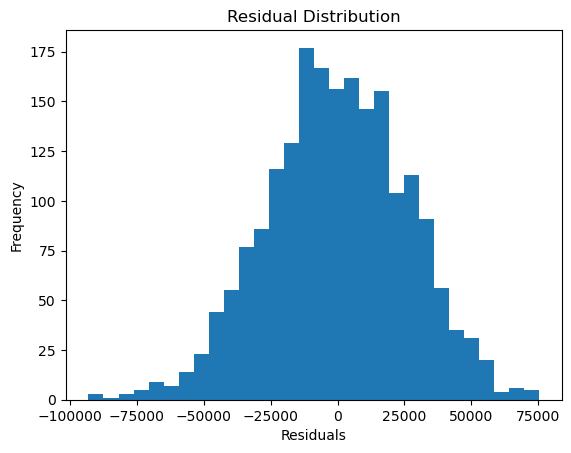

In [29]:
pipeline.fit(X, y)
y_final_pred = pipeline.predict(X)
residuals = y - y_final_pred
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

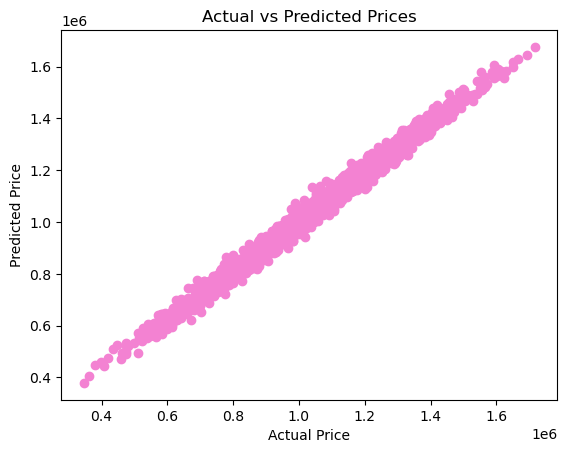

In [30]:
plt.figure()
plt.scatter(y, y_final_pred,color="#f382d2")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [31]:
feature_names=pipeline.named_steps['preprocessor'].get_feature_names_out()
importance=pipeline.named_steps['model'].feature_importances_
fi=pd.DataFrame({
    'Feature':feature_names,
    'Importance':importance
}).sort_values(by='Importance',ascending=False)

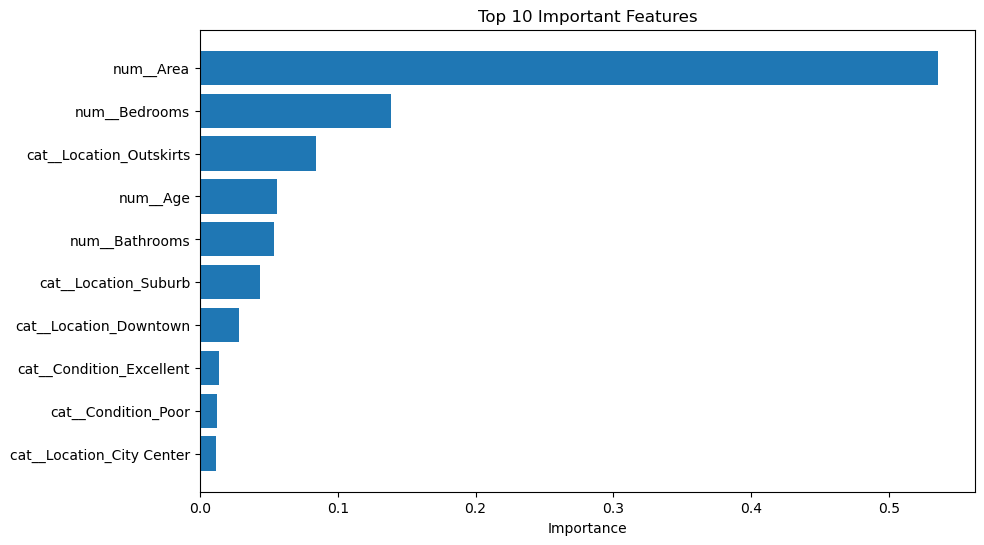

In [32]:
plt.figure(figsize=(10,6))
plt.barh(fi['Feature'][:10], fi['Importance'][:10])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

In [33]:
joblib.dump(pipeline,'house.pkl')

['house.pkl']

In [34]:
model = joblib.load(r'C:\Users\LENOVO\house.pkl')
test_house = pd.DataFrame({
    "Area": [4000],
    "Bedrooms": [4],
    "Bathrooms": [3],
    "Age": [5],
    "Location": ["Urban"],
    "Condition": ["Excellent"],
    "Garage": ["Yes"]
})

prediction = model.predict(test_house)
rounded_price=int(round(prediction[0]))
print("Predicted Price:",rounded_price)

Predicted Price: 1431971
